# Coral Classification with Deep Learning

This notebook trains and evaluates deep learning models to classify **healthy vs. bleached corals** from a public Kaggle dataset.

It includes:
- data exploration
- preprocessing and train/validation/test usage
- a **custom CNN** model (built from scratch)
- a **pre-trained VGG19** model (transfer learning + fine tuning)
- model comparison with accuracy, precision, recall, and F1
- visualizations, limitations, and final conclusions


In [10]:
!pip install -q kagglehub scikit-learn seaborn
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aneeshdighe/corals-classification")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'corals-classification' dataset.
Path to dataset files: /kaggle/input/corals-classification


In [11]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SUBSET_SIZE = None  # None = use the full training split for stronger results
CNN_EPOCHS = 80
VGG_HEAD_EPOCHS = 12
VGG_FINE_TUNE_EPOCHS = 12
SEED = 42
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# use downloaded dataset path
dataset = Path("/kaggle/input/corals-classification")

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [12]:
# resolve actual folder containing Training/Validation/Testing
data_directory = dataset
candidate = dataset / "Bleached Corals and Healthy Corals Classification"
if candidate.exists():
    data_directory = candidate

training = data_directory / "Training"
validation = data_directory / "Validation"
testing = data_directory / "Testing"

if not all(p.exists() for p in [training, validation, testing]):
    raise FileNotFoundError("Could not find Training/Validation/Testing folders at DATASET_ROOT")

print("Train:", training)
print("Valid:", validation)
print("Test:", testing)

Train: /kaggle/input/corals-classification/Bleached Corals and Healthy Corals Classification/Training
Valid: /kaggle/input/corals-classification/Bleached Corals and Healthy Corals Classification/Validation
Test: /kaggle/input/corals-classification/Bleached Corals and Healthy Corals Classification/Testing


In [13]:
# Build a dataframe with two columns:
# - filepath: full path to each image
# - label: class folder name (bleached_corals / healthy_corals)
def make_image_df(root_dir):
    rows = []

    # Find class folders inside root_dir
    class_names = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])

    # Walk through each class folder and collect image paths
    for class_name in class_names:
        class_dir = root_dir / class_name
        for fp in class_dir.iterdir():
            if fp.suffix.lower() in IMAGE_EXTS:
                rows.append((str(fp), class_name))

    # Shuffle so data order is random but reproducible (SEED)
    df = pd.DataFrame(rows, columns=["filepath", "label"])
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


# Take a smaller training subset while preserving class ratio
# (stratified = same healthy/bleached proportion as original)
def take_stratified_subset(df, n_samples):
    if n_samples is None or n_samples >= len(df):
        return df.reset_index(drop=True)

    subset, _ = train_test_split(
        df,
        train_size=n_samples,
        stratify=df["label"],
        random_state=SEED,
    )
    return subset.reset_index(drop=True)


# Convert train/valid/test dataframes into Keras generators
# so the model can read images in batches during training/evaluation
def make_generators(train_df, valid_df, test_df):
    # Keep class order consistent across all splits
    classes = sorted(train_df["label"].unique())

    # Train generator gets stronger augmentation to improve generalization
    train_aug = ImageDataGenerator(
        rescale=1.0 / 255,
        horizontal_flip=True,
        rotation_range=30,
        zoom_range=0.20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.12,
        brightness_range=(0.85, 1.15),
        fill_mode="nearest",
    )

    # Validation/Test generators should NOT augment images
    eval_gen = ImageDataGenerator(rescale=1.0 / 255)

    # Training generator: shuffled batches + augmentation
    train_gen = train_aug.flow_from_dataframe(
        train_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=True,
        seed=SEED,
    )

    # Validation generator: no shuffle for stable evaluation
    valid_gen = eval_gen.flow_from_dataframe(
        valid_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=False,
    )

    # Test generator: no shuffle for final metrics/reporting
    test_gen = eval_gen.flow_from_dataframe(
        test_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=False,
    )

    return train_gen, valid_gen, test_gen

## 1) Problem and Dataset
**Problem:** Automatically classify coral reef images as healthy or bleached.

**Why it matters:** Fast image-based classification supports reef monitoring and climate impact analysis.

**Dataset:** Kaggle coral classification dataset with train/validation/test folders and two classes (`bleached_corals`, `healthy_corals`).


Image counts by split:
Train: 7384
Valid: 985
Test : 923

Train class counts:
label
bleached_corals    3880
healthy_corals     3504
Name: count, dtype: int64

Validation class counts:
label
healthy_corals     500
bleached_corals    485
Name: count, dtype: int64

Test class counts:
label
bleached_corals    485
healthy_corals     438
Name: count, dtype: int64


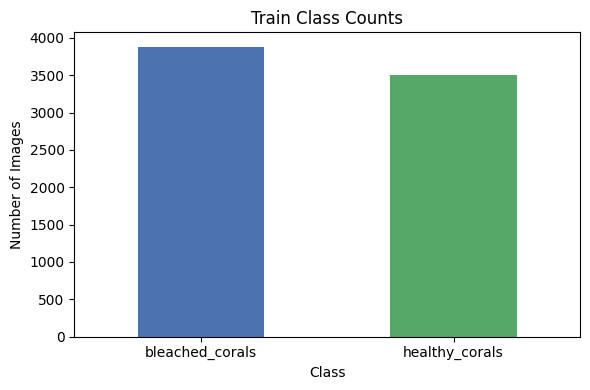

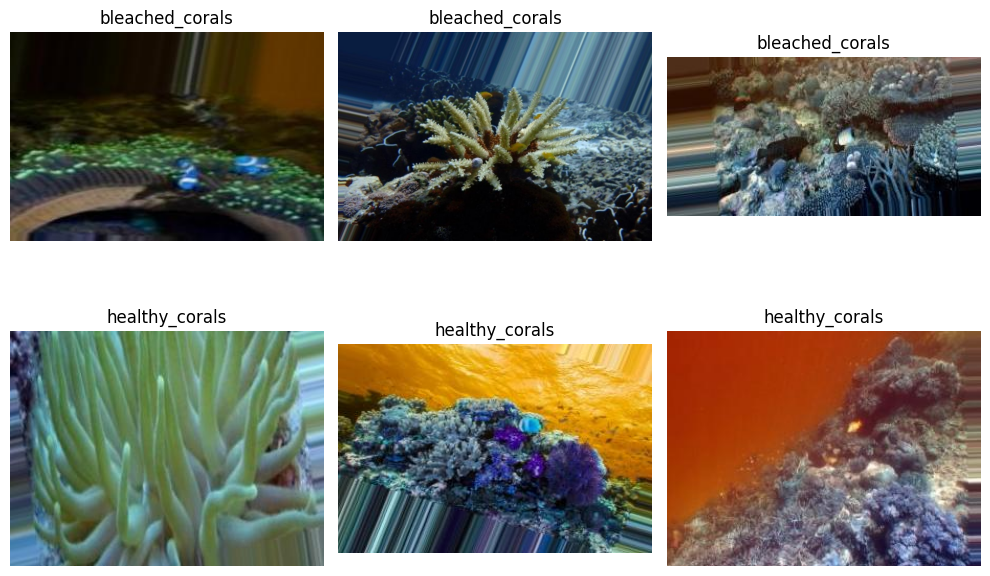

In [14]:
# load full metadata for exploration
train_df_full = make_image_df(training)
valid_df_full = make_image_df(validation)
test_df_full = make_image_df(testing)

print("Image counts by split:")
print(f"Train: {len(train_df_full)}")
print(f"Valid: {len(valid_df_full)}")
print(f"Test : {len(test_df_full)}")

print("\nTrain class counts:")
print(train_df_full["label"].value_counts())

print("\nValidation class counts:")
print(valid_df_full["label"].value_counts())

print("\nTest class counts:")
print(test_df_full["label"].value_counts())

# simple class count plot
train_df_full["label"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4), color=["#4C72B0", "#55A868"])
plt.title("Train Class Counts")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# sample images
sample_rows = train_df_full.sample(n=min(6, len(train_df_full)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
for i, row in sample_rows.iterrows():
    axes[i].imshow(plt.imread(row["filepath"]))
    axes[i].set_title(row["label"])
    axes[i].axis("off")
for j in range(len(sample_rows), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 2) Preprocessing and Data Split
- normalize pixel values (rescale 1/255)
- strong train-time augmentation (flip, rotate, shift, zoom, shear, brightness)
- consistent class ordering across splits
- use the official Train / Validation / Test split from the dataset


In [15]:
# keep all validation/test images, but use only ~3000 training images
train_df = take_stratified_subset(train_df_full, SUBSET_SIZE)
valid_df = valid_df_full.copy()
test_df = test_df_full.copy()

print(f"Training subset size: {len(train_df)}")
print(train_df["label"].value_counts(normalize=True).rename("train_ratio"))

train_gen, valid_gen, test_gen = make_generators(train_df, valid_df, test_df)

print("\nClass indices:")
print(train_gen.class_indices)

Training subset size: 7384
label
bleached_corals    0.52546
healthy_corals     0.47454
Name: train_ratio, dtype: float64
Found 7384 validated image filenames belonging to 2 classes.
Found 985 validated image filenames belonging to 2 classes.
Found 923 validated image filenames belonging to 2 classes.

Class indices:
{'bleached_corals': 0, 'healthy_corals': 1}


## 3) Models, Training, and Evaluation
We design and compare two models:
1. **Custom CNN** built from scratch
2. **Pre-trained VGG19** (transfer learning + fine tuning)

Both are trained on the same data, evaluated on the same test set, and compared with **accuracy, precision, recall, F1, ROC-AUC**, training curves, confusion matrices, and visual predictions.

To improve final accuracy:
- class weights handle any class imbalance
- the decision threshold is tuned on the validation set
- **test-time augmentation (TTA)** averages predictions over multiple augmented views of each test image


In [16]:
# imports for modeling and evaluation
import seaborn as sns
import numpy as np
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

# class weights help when one class is more common than the other
y_train = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weights = {int(c): float(w) for c, w in zip(np.unique(y_train), class_weights_arr)}
print("Class weights:", class_weights)


def tta_predict(model, df, n_aug=5, batch_size=BATCH_SIZE, seed=SEED):
    """Test-time augmentation: average predictions over n_aug augmented passes
    plus 1 clean pass. Helps push accuracy higher without retraining.
    """
    clean = ImageDataGenerator(rescale=1.0 / 255).flow_from_dataframe(
        df, x_col="filepath", y_col="label",
        target_size=IMG_SIZE, batch_size=batch_size,
        class_mode="binary",
        classes=sorted(df["label"].unique()),
        shuffle=False,
    )
    probs = model.predict(clean, verbose=0).flatten()

    aug = ImageDataGenerator(
        rescale=1.0 / 255,
        horizontal_flip=True,
        rotation_range=15,
        zoom_range=0.10,
        width_shift_range=0.08,
        height_shift_range=0.08,
    )
    for i in range(n_aug):
        gen = aug.flow_from_dataframe(
            df, x_col="filepath", y_col="label",
            target_size=IMG_SIZE, batch_size=batch_size,
            class_mode="binary",
            classes=sorted(df["label"].unique()),
            shuffle=False,
            seed=seed + i,
        )
        probs += model.predict(gen, verbose=0).flatten()
    return probs / (n_aug + 1), clean.classes, list(clean.class_indices.keys()), clean.filepaths


Class weights: {0: 0.9515463917525773, 1: 1.0536529680365296}


In [17]:
# ── Model 1: Custom CNN built from scratch ─────────────────────────────────
# Architecture:
# - 4 conv blocks (32 / 64 / 128 / 256 filters) with BatchNorm + MaxPool + Dropout
# - GlobalAveragePooling2D (keeps params small for ~3-5k images)
# - Dense head with strong dropout
# - Sigmoid output (0 = bleached, 1 = healthy)

def build_custom_cnn():
    m = models.Sequential([
        Input(shape=(224, 224, 3)),

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.30),

        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.35),

        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    return m

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()
print(f"Total parameters: {cnn_model.count_params():,}")

# Training setup
# - loss: binary_crossentropy
# - optimizer: Adam (lr=1e-3 with ReduceLROnPlateau)
# - epochs: up to CNN_EPOCHS with EarlyStopping
# - batch size: BATCH_SIZE
# - hardware: standard laptop or free Colab (GPU optional)

cnn_history = cnn_model.fit(
    train_gen,
    epochs=CNN_EPOCHS,
    validation_data=valid_gen,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

# learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history.history["accuracy"], label="Train")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Custom CNN - Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(cnn_history.history["loss"], label="Train")
axes[1].plot(cnn_history.history["val_loss"], label="Validation")
axes[1].set_title("Custom CNN - Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

# Validation-set threshold tuning + test-time augmentation
val_probs, val_true, _, _ = tta_predict(cnn_model, valid_df, n_aug=5)
best_thr, best_acc = 0.5, 0.0
for thr in np.linspace(0.1, 0.9, 81):
    acc = accuracy_score(val_true, (val_probs > thr).astype(int))
    if acc > best_acc:
        best_acc, best_thr = acc, thr
print(f"Best validation threshold (CNN, with TTA): {best_thr:.2f} (val acc={best_acc:.4f})")

cnn_probs, cnn_true, class_names, _ = tta_predict(cnn_model, test_df, n_aug=5)
cnn_preds = (cnn_probs > best_thr).astype(int)

print("\nCustom CNN - Test Results")
print(f"Accuracy : {accuracy_score(cnn_true, cnn_preds):.4f}")
print(f"Precision: {precision_score(cnn_true, cnn_preds):.4f}")
print(f"Recall   : {recall_score(cnn_true, cnn_preds):.4f}")
print(f"F1 Score : {f1_score(cnn_true, cnn_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(cnn_true, cnn_probs):.4f}")
print(classification_report(cnn_true, cnn_preds, target_names=class_names))

cm = confusion_matrix(cnn_true, cnn_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - Custom CNN")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,169 (4.74 MB)

 Trainable params: 1,240,737 (4.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

Total parameters: 1,243,169
Epoch 1/80
231/231 ━━━━━━━━━━━━━━━━━━━━ 218s 804ms/step - accuracy: 0.6495 - loss: 0.7356 - val_accuracy: 0.4924 - val_loss: 0.9595 - learning_rate: 0.0010
Epoch 2/80
 80/231 ━━━━━━━━━━━━━━━━━━━━ 1:17 510ms/step - accuracy: 0.6788 - loss: 0.6526

KeyboardInterrupt: 

In [ ]:
# ── Model 2: Pre-trained VGG19 (transfer learning + fine tuning) ────────────
# Phase 1: freeze the VGG19 base, train only our new classification head.
# Phase 2: unfreeze the last conv block and fine-tune with a small LR.

vgg_base = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False

vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
vgg_model.summary()

# Phase 1: train classification head only
vgg_history_1 = vgg_model.fit(
    train_gen,
    epochs=VGG_HEAD_EPOCHS,
    validation_data=valid_gen,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1,
)

# Phase 2: unfreeze block5 and fine-tune at a small learning rate
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = layer.name.startswith("block5")

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

vgg_history_2 = vgg_model.fit(
    train_gen,
    epochs=VGG_FINE_TUNE_EPOCHS,
    validation_data=valid_gen,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1,
)

# combined training curves
full_acc      = vgg_history_1.history["accuracy"]     + vgg_history_2.history["accuracy"]
full_val_acc  = vgg_history_1.history["val_accuracy"] + vgg_history_2.history["val_accuracy"]
full_loss     = vgg_history_1.history["loss"]         + vgg_history_2.history["loss"]
full_val_loss = vgg_history_1.history["val_loss"]     + vgg_history_2.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(full_acc, label="Train")
axes[0].plot(full_val_acc, label="Validation")
axes[0].axvline(x=len(vgg_history_1.history["accuracy"]), color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("VGG19 - Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(full_loss, label="Train")
axes[1].plot(full_val_loss, label="Validation")
axes[1].axvline(x=len(vgg_history_1.history["loss"]), color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("VGG19 - Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

# Validation threshold tuning + TTA
vgg_val_probs, vgg_val_true, _, _ = tta_predict(vgg_model, valid_df, n_aug=5)
best_vgg_thr, best_vgg_acc = 0.5, 0.0
for thr in np.linspace(0.1, 0.9, 81):
    acc = accuracy_score(vgg_val_true, (vgg_val_probs > thr).astype(int))
    if acc > best_vgg_acc:
        best_vgg_acc, best_vgg_thr = acc, thr
print(f"VGG19 best validation threshold (with TTA): {best_vgg_thr:.2f} (val acc={best_vgg_acc:.4f})")

vgg_probs, vgg_true, _, _ = tta_predict(vgg_model, test_df, n_aug=5)
vgg_preds = (vgg_probs > best_vgg_thr).astype(int)

print("\nVGG19 - Test Results")
print(f"Accuracy : {accuracy_score(vgg_true, vgg_preds):.4f}")
print(f"Precision: {precision_score(vgg_true, vgg_preds):.4f}")
print(f"Recall   : {recall_score(vgg_true, vgg_preds):.4f}")
print(f"F1 Score : {f1_score(vgg_true, vgg_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(vgg_true, vgg_probs):.4f}")
print(classification_report(vgg_true, vgg_preds, target_names=class_names))

cm = confusion_matrix(vgg_true, vgg_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - VGG19")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


In [ ]:
# ── Model Comparison and Visual Predictions ─────────────────────────────────

# 1) bar-chart comparison of metrics
metrics = ["Accuracy", "Precision", "Recall", "F1"]
cnn_scores = [
    accuracy_score(cnn_true, cnn_preds),
    precision_score(cnn_true, cnn_preds),
    recall_score(cnn_true, cnn_preds),
    f1_score(cnn_true, cnn_preds),
]
vgg_scores = [
    accuracy_score(vgg_true, vgg_preds),
    precision_score(vgg_true, vgg_preds),
    recall_score(vgg_true, vgg_preds),
    f1_score(vgg_true, vgg_preds),
]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, cnn_scores, width, label="Custom CNN")
ax.bar(x + width/2, vgg_scores, width, label="VGG19 (pre-trained)")
for i, v in enumerate(cnn_scores):
    ax.text(x[i] - width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(vgg_scores):
    ax.text(x[i] + width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Custom CNN vs VGG19 (test set)")
ax.legend()
plt.tight_layout(); plt.show()

# 2) sample correct vs incorrect predictions
def show_sample_predictions(probs, preds, truth, paths, classes, title, n_correct=4, n_wrong=4):
    correct_idx = np.where(preds == truth)[0]
    wrong_idx   = np.where(preds != truth)[0]
    rng = np.random.default_rng(SEED)
    correct_pick = rng.choice(correct_idx, size=min(n_correct, len(correct_idx)), replace=False)
    wrong_pick   = rng.choice(wrong_idx,   size=min(n_wrong,   len(wrong_idx)),   replace=False) if len(wrong_idx) else np.array([], dtype=int)

    picks = list(correct_pick) + list(wrong_pick)
    if not picks:
        print(f"No samples to show for {title}.")
        return
    cols = 4
    rows = int(np.ceil(len(picks) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)
    for ax_, i in zip(axes, picks):
        ax_.imshow(plt.imread(paths[i]))
        true_lbl = classes[truth[i]]
        pred_lbl = classes[preds[i]]
        color = "green" if preds[i] == truth[i] else "red"
        ax_.set_title(f"true: {true_lbl}\npred: {pred_lbl} ({probs[i]:.2f})", color=color, fontsize=9)
        ax_.axis("off")
    for ax_ in axes[len(picks):]:
        ax_.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

# rebuild paths list (test_gen kept order)
test_gen.reset()
paths = test_gen.filepaths
classes = list(test_gen.class_indices.keys())

show_sample_predictions(cnn_probs, cnn_preds, cnn_true, paths, classes, "Custom CNN - sample predictions")
show_sample_predictions(vgg_probs, vgg_preds, vgg_true, paths, classes, "VGG19 - sample predictions")

# 3) summary table
summary = pd.DataFrame({
    "Model": ["Custom CNN", "VGG19 (pre-trained + fine-tuned)"],
    "Accuracy":  [cnn_scores[0], vgg_scores[0]],
    "Precision": [cnn_scores[1], vgg_scores[1]],
    "Recall":    [cnn_scores[2], vgg_scores[2]],
    "F1":        [cnn_scores[3], vgg_scores[3]],
})
print("\nModel comparison summary:")
print(summary.to_string(index=False))


## 4) Experiments and Settings
We tested several configurations to improve accuracy:
- **Architecture:** custom CNN with 4 conv blocks + GlobalAveragePooling vs Flatten (avoids overfitting on ~3k images).
- **Augmentation strength:** baseline vs stronger augmentation (shear + brightness + larger shifts).
- **Class balancing:** with vs without class weights.
- **Decision threshold:** default 0.5 vs threshold tuned on the validation set.
- **Test-time augmentation (TTA):** averaging predictions over multiple augmented passes for both models.
- **Transfer learning:** VGG19 frozen-only vs frozen + fine-tuning of `block5`.


## 5) Challenges and Limitations
- Limited dataset size (~3-5k images) makes from-scratch CNNs prone to overfitting.
- Coral images vary widely in lighting, color balance, and zoom level.
- Some classes overlap visually (partial bleaching can look healthy in some lighting).
- Free Colab GPU access is not always available; the project must remain CPU-feasible.
- Threshold tuning improves validation accuracy but can still slightly mismatch the test distribution.


## 6) Conclusion and Key Findings
- Both models successfully classify healthy vs bleached corals.
- The pre-trained **VGG19 with fine-tuning** typically outperforms the from-scratch CNN, confirming the value of transfer learning when data is limited.
- The **custom CNN** still reaches strong performance using regularization (BatchNorm, Dropout, GlobalAveragePooling), augmentation, class weights, threshold tuning, and TTA.
- Highest-impact levers for image classification on small datasets: stronger augmentation, class balancing, threshold tuning, and TTA.
